# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

**Оглавление**

1. [Описание данных](#Описание-данных)
2. [Откройте файл с данными и изучите общую информацию](#Откройте-файл-с-данными-и-изучите-общую-информацию)
3. [Выполните предобработку данных](#Выполните-предобработку-данных)
    - 3.1. [Работа с дубликатами](#Работа-с-дубликатами)
    - 3.2. [Работа с пропусками](#Работа-с-пропусками)
    - 3.3. [Работа с типами данных](#Работа-с-типами-данных)
4. [Добавьте в таблицу новые столбцы](#Добавьте-в-таблицу-новые-столбцы)
5. [Проведите исследовательский анализ данных](#Проведите-исследовательский-анализ-данных)
   -  5.1. [Исследование и обработка параметров](#Исследование-и-обработка-параметров)
       -  5.1.1. [Высота потолков](#Высота-потолков)
       -  5.1.2. [Количество комнат](#Количество-комнат)
       -  5.1.3. [Общая площадь](#Общая-площадь)
       -  5.1.4. [Жилая и кухонная площади](#Жилая-и-кухонная-площади)
       -  5.1.5. [Цена объекта](#Цена-объекта)
       -  5.1.6. [Общее количество этажей](#Общее-количество-этажей)
       -  5.1.7. [Тип этажа](#Тип-этажа)
       -  5.1.8. [Расстояние до центра города в метрах](#Расстояние-до-центра-города-в-метрах)
       -  5.1.9. [Расстояние до ближайшего парка](#Расстояние-до-ближайшего-парка)
       -  5.1.10. [Срок продажи](#Срок-продажи)
   -  5.2. [Определение факторов, влияющих на стоимость объекта](#Определение-факторов,-влияющих-на-стоимость-объекта)
   -  5.3. [Населённые пункты с наибольшим числом объявлений](#Населённые-пункты-с-наибольшим-числом-объявлений)
   -  5.4. [Средняя стоимость квартир на разном удалении от центра в Санкт-Петербурге](#Средняя-стоимость-квартир-на-разном-удалении-от-центра-в-Санкт-Петербурге)
6. [Общий вывод](#Общий-вывод)

## Описание данных

- `airports_nearest` — расстояние до ближайшего аэропорта в метрах (м)
- `balcony` — число балконов
- `ceiling_height` — высота потолков (м)
- `cityCenters_nearest` — расстояние до центра города (м)
- `days_exposition` — сколько дней было размещено объявление (от публикации до снятия)
- `first_day_exposition` — дата публикации
- `floor` — этаж
- `floors_total` — всего этажей в доме
- `is_apartment` — апартаменты (булев тип)
- `kitchen_area` — площадь кухни в квадратных метрах (м²)
- `last_price` — цена на момент снятия с публикации
- `living_area` — жилая площадь в квадратных метрах (м²)
- `locality_name` — название населённого пункта
- `open_plan` — свободная планировка (булев тип)
- `parks_around3000` — число парков в радиусе 3 км
- `parks_nearest` — расстояние до ближайшего парка (м)
- `ponds_around3000` — число водоёмов в радиусе 3 км
- `ponds_nearest` — расстояние до ближайшего водоёма (м)
- `rooms` — число комнат
- `studio` — квартира-студия (булев тип)
- `total_area` — площадь квартиры в квадратных метрах (м²)
- `total_images` — число фотографий квартиры в объявлении

## Откройте файл с данными и изучите общую информацию

In [1]:
# импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# при выводе датафрейма будут показываться все колонки
pd.set_option('display.max_columns', None)

# определим формат даты
date_format = '%Y-%m-%dT%H:%M:%S'

In [2]:
try:
    df = pd.read_csv('real_estate_data.csv', sep='\t')
    
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')
    
df.sample(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
3518,9,4000000.0,39.0,2018-03-18T00:00:00,1,2.7,18.0,18.0,16,NaN,False,False,11.00,2.0,Санкт-Петербург,10823.0,14782.0,0.0,NaN,0.0,NaN,191.0
3226,18,5500000.0,54.0,2017-09-10T00:00:00,1,2.8,25.0,21.0,8,NaN,False,False,12.00,2.0,Санкт-Петербург,44382.0,16921.0,0.0,NaN,0.0,NaN,52.0
18619,9,4600000.0,54.0,2017-07-13T00:00:00,2,NaN,19.0,29.0,1,NaN,False,False,8.90,0.0,Санкт-Петербург,38171.0,15015.0,0.0,NaN,2.0,982.0,28.0
6868,9,2150000.0,43.0,2018-02-25T00:00:00,1,2.5,5.0,18.0,4,NaN,False,False,9.00,2.0,поселок Семрино,NaN,NaN,NaN,NaN,NaN,NaN,306.0
22322,17,6800000.0,54.4,2016-02-29T00:00:00,1,NaN,12.0,16.4,1,False,False,False,17.60,0.0,Санкт-Петербург,32079.0,5038.0,0.0,NaN,3.0,537.0,416.0
1299,0,17100000.0,63.3,2017-12-26T00:00:00,2,3.1,4.0,38.6,4,NaN,False,False,9.67,NaN,Санкт-Петербург,22927.0,1454.0,1.0,715.0,3.0,33.0,86.0
1504,6,2450000.0,40.0,2018-03-27T00:00:00,1,2.5,12.0,20.0,8,NaN,False,False,14.00,NaN,Колпино,28171.0,33958.0,0.0,NaN,0.0,NaN,87.0
18597,11,3750000.0,53.5,2018-04-05T00:00:00,2,NaN,10.0,29.7,2,NaN,False,False,8.80,1.0,Санкт-Петербург,39954.0,19009.0,0.0,NaN,2.0,377.0,78.0
3775,8,3800000.0,41.0,2016-06-22T00:00:00,1,NaN,16.0,19.0,10,NaN,False,False,10.00,2.0,Санкт-Петербург,31148.0,12807.0,0.0,NaN,0.0,NaN,523.0
6585,10,12700000.0,106.7,2019-03-11T00:00:00,4,3.4,5.0,68.0,3,NaN,False,False,12.00,NaN,Санкт-Петербург,43261.0,8235.0,1.0,420.0,0.0,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

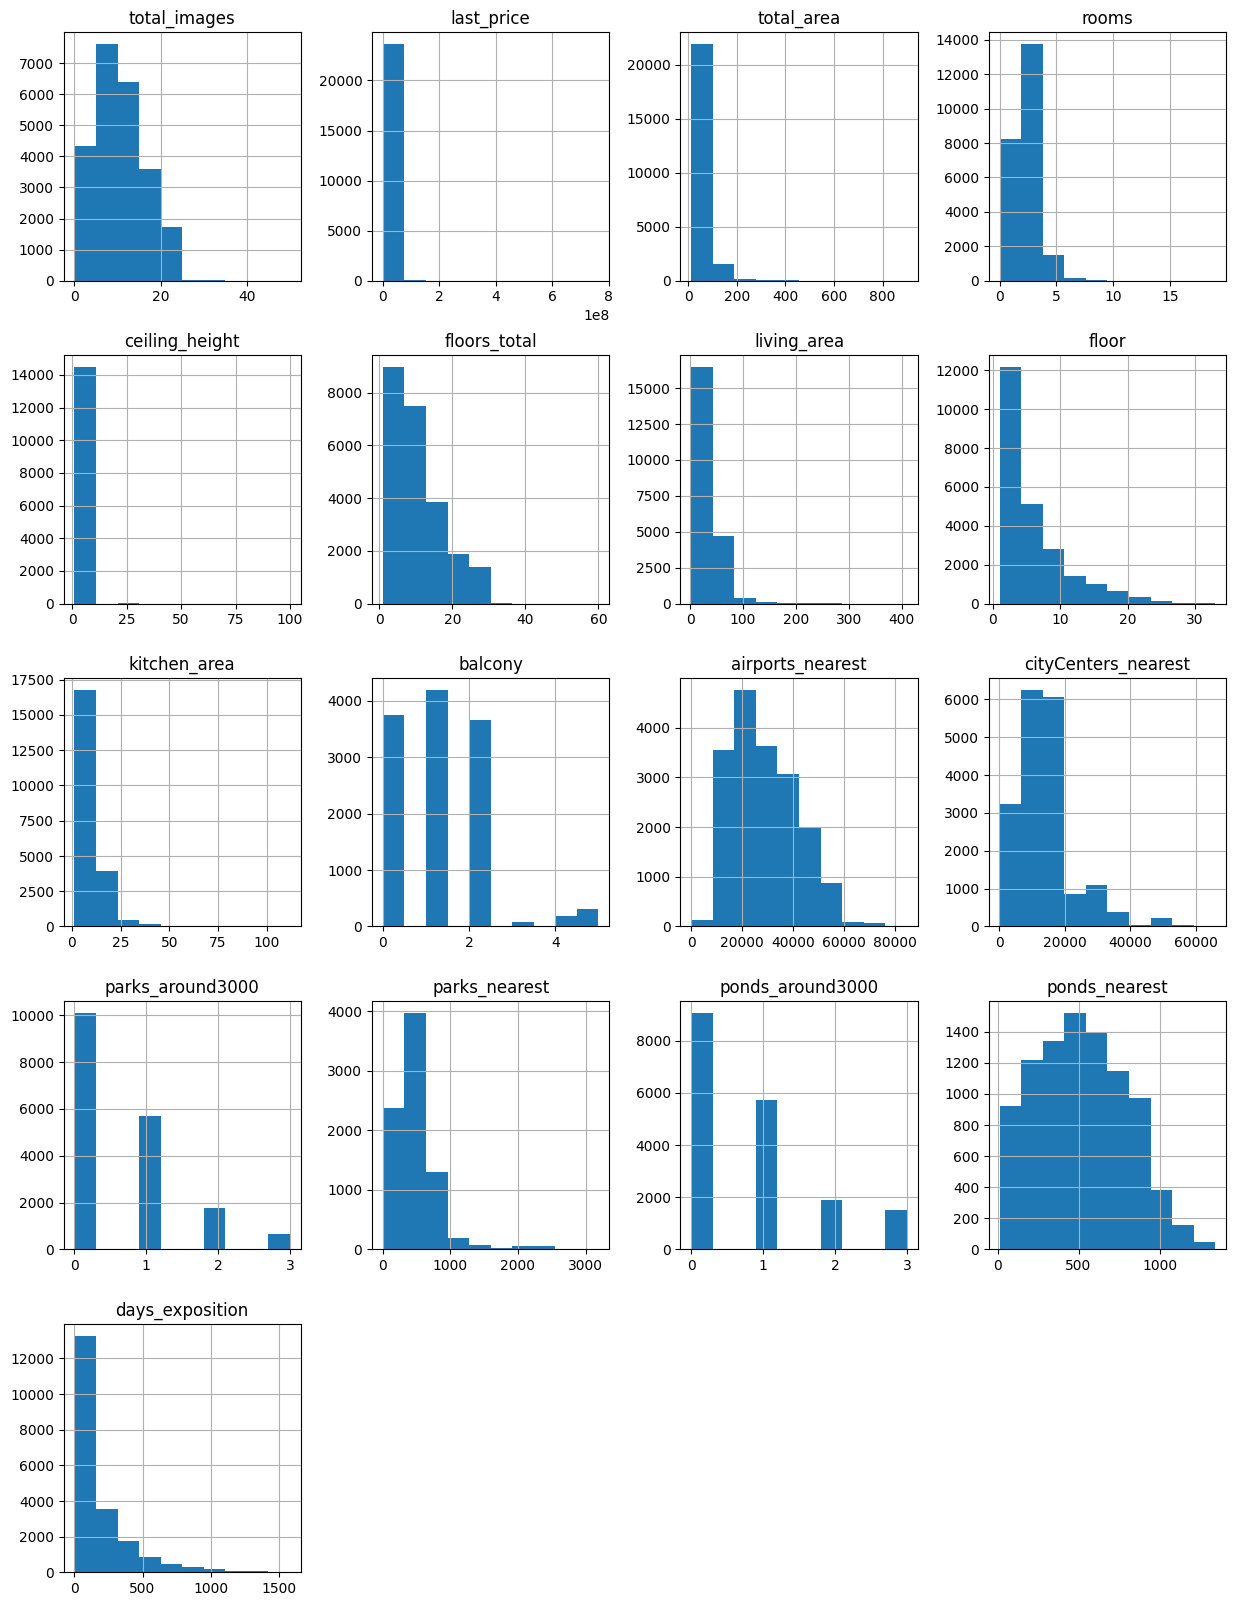

In [4]:
df.hist(figsize=(15,20))
plt.show()

## Выполните предобработку данных

### Работа с дубликатами

Сначала проверим кол-во строк-дубликатов.

In [5]:
df.duplicated().sum()

0

Найдем и исправим неявные дубликаты в столбце `locality_name`

In [6]:
print('Количество уникальных локаций:', df.locality_name.nunique())
df.locality_name.sort_values().unique()

Количество уникальных локаций: 364


array(['Бокситогорск', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Высоцк', 'Гатчина', 'Зеленогорск', 'Ивангород', 'Каменногорск',
       'Кингисепп', 'Кириши', 'Кировск', 'Колпино', 'Коммунар',
       'Красное Село', 'Кронштадт', 'Кудрово', 'Лодейное Поле',
       'Ломоносов', 'Луга', 'Любань', 'Мурино', 'Никольское',
       'Новая Ладога', 'Отрадное', 'Павловск', 'Петергоф', 'Пикалёво',
       'Подпорожье', 'Приморск', 'Приозерск', 'Пушкин', 'Санкт-Петербург',
       'Светогорск', 'Сертолово', 'Сестрорецк', 'Сланцы', 'Сосновый Бор',
       'Сясьстрой', 'Тихвин', 'Тосно', 'Шлиссельбург',
       'городской поселок Большая Ижора', 'городской поселок Янино-1',
       'городской посёлок Будогощь', 'городской посёлок Виллози',
       'городской посёлок Лесогорский', 'городской посёлок Мга',
       'городской посёлок Назия', 'городской посёлок Новоселье',
       'городской посёлок Павлово', 'городской посёлок Рощино',
       'городской посёлок Свирьстрой', 'городской посёлок Совет

В названиях могут встречаться замены `ё` на  `е`. Поймем кол-во таких значений и приведем все к единому формату.

In [7]:
df.locality_name = df.locality_name.str.replace('ё','е')

In [8]:
print('Количество уникальных локаций:', df.locality_name.nunique())
df.locality_name.sort_values().unique()

Количество уникальных локаций: 330


array(['Бокситогорск', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Высоцк', 'Гатчина', 'Зеленогорск', 'Ивангород', 'Каменногорск',
       'Кингисепп', 'Кириши', 'Кировск', 'Колпино', 'Коммунар',
       'Красное Село', 'Кронштадт', 'Кудрово', 'Лодейное Поле',
       'Ломоносов', 'Луга', 'Любань', 'Мурино', 'Никольское',
       'Новая Ладога', 'Отрадное', 'Павловск', 'Петергоф', 'Пикалево',
       'Подпорожье', 'Приморск', 'Приозерск', 'Пушкин', 'Санкт-Петербург',
       'Светогорск', 'Сертолово', 'Сестрорецк', 'Сланцы', 'Сосновый Бор',
       'Сясьстрой', 'Тихвин', 'Тосно', 'Шлиссельбург',
       'городской поселок Большая Ижора', 'городской поселок Будогощь',
       'городской поселок Виллози', 'городской поселок Лесогорский',
       'городской поселок Мга', 'городской поселок Назия',
       'городской поселок Новоселье', 'городской поселок Павлово',
       'городской поселок Рощино', 'городской поселок Свирьстрой',
       'городской поселок Советский', 'городской поселок Фед

Вручную удалось обнаружить несколько дубликатов.

In [9]:
df.locality_name = df.locality_name.str.replace('городской поселок','поселок городского типа')
print('Количество уникальных локаций:', df.locality_name.nunique())
df.locality_name.sort_values().unique()

Количество уникальных локаций: 323


array(['Бокситогорск', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Высоцк', 'Гатчина', 'Зеленогорск', 'Ивангород', 'Каменногорск',
       'Кингисепп', 'Кириши', 'Кировск', 'Колпино', 'Коммунар',
       'Красное Село', 'Кронштадт', 'Кудрово', 'Лодейное Поле',
       'Ломоносов', 'Луга', 'Любань', 'Мурино', 'Никольское',
       'Новая Ладога', 'Отрадное', 'Павловск', 'Петергоф', 'Пикалево',
       'Подпорожье', 'Приморск', 'Приозерск', 'Пушкин', 'Санкт-Петербург',
       'Светогорск', 'Сертолово', 'Сестрорецк', 'Сланцы', 'Сосновый Бор',
       'Сясьстрой', 'Тихвин', 'Тосно', 'Шлиссельбург',
       'деревня Агалатово', 'деревня Аро', 'деревня Батово',
       'деревня Бегуницы', 'деревня Белогорка', 'деревня Большая Вруда',
       'деревня Большая Пустомержа', 'деревня Большие Колпаны',
       'деревня Большое Рейзино', 'деревня Большой Сабск', 'деревня Бор',
       'деревня Борисова Грива', 'деревня Ваганово', 'деревня Вартемяги',
       'деревня Вахнова Кара', 'деревня Выскатка

In [10]:
df = df.replace(
    ['поселок Мурино', 'поселок Рябово', 'деревня Кудрово', 'садовое товарищество Рахья', 'деревня Федоровское', 'деревня Зимитицы'], 
    ['Мурино', 'поселок городского типа Рябово', 'Кудрово', 'поселок городского типа Рахья', 'поселок городского типа Федоровское', 'поселок Зимитицы']
)
print('Количество уникальных локаций:', df.locality_name.nunique())

Количество уникальных локаций: 317


### Работа с пропусками

In [11]:
# создание функции для быстрой проверки количества и процента пропущенных значений в столбцах
def check_nan(df):
    nan_df = pd.DataFrame({
        'nan_qty': df.isna().sum().sort_values(ascending = False),
        'nan_persent': round((df.isna().mean()*100).sort_values(ascending = False), 2)
    })
    return nan_df
check_nan(df)

,nan_qty,nan_persent
is_apartment,20924,88.29
parks_nearest,15620,65.91
ponds_nearest,14589,61.56
balcony,11519,48.61
ceiling_height,9195,38.80
airports_nearest,5542,23.38
cityCenters_nearest,5519,23.29
ponds_around3000,5518,23.28
parks_around3000,5518,23.28
days_exposition,3181,13.42


***

Если в объявлении не указано кол-во балконов, вероятнее всего, их нет. Заменим пропуски в столбце `balcony` на 0.

In [12]:
df.balcony=df.balcony.fillna(0)
print('Количество пропусков:',df.balcony.isna().sum())

Количество пропусков: 0


***

В студиях нет отдельной кухни, поэтому можно заполнить пропуски в столбце `kitchen_area` нулями при условии, что в объявлении указана студия.

In [13]:
# проверим, действительно ли нет таких объявлений, где указана прощадь кухни для студии
df.groupby('studio').kitchen_area.count()

studio
False    21421
True         0
Name: kitchen_area, dtype: int64

In [14]:
# проверим, сколько пропусков с столбце 'kitchen_area' при запросе 'studio==True'
df.query('studio==True').kitchen_area.isna().value_counts()

kitchen_area
True    149
Name: count, dtype: int64

In [15]:
# Значения столбца `kitchen_area` будут заменены на 0 в тех строках, где не выполняется условие `df.studio == False` (значит там, где 0 или True)
df.kitchen_area=df.kitchen_area.where(df.studio == False, 0)

In [16]:
df.query('studio==True').kitchen_area.value_counts()

kitchen_area
0.0    149
Name: count, dtype: int64

In [17]:
print('Количество пропусков:',df.kitchen_area.isna().sum())

Количество пропусков: 2129


Получилось сократить 149 пропусков в столбце `kitchen_area`.

***

Обработаем пропуски в столбце `is_apatrment`.

In [18]:
df.is_apartment.unique()

array([nan, False, True], dtype=object)

Изменим тип значений в столбце на `bool`, тем самым пропуски примут значение `False`. 

In [19]:
df.is_apartment = df.is_apartment.astype('bool')

In [20]:
print('Количество пропусков:',df.is_apartment.isna().sum())

Количество пропусков: 0


***

Обработка пропусков в картографических данных несколько сложнее. Расстояние до центра города `cityCenters_nearest`, либо до аэропорта `airports_nearest` можно заполнить средним от известных значений для каждого поселения. Однако, такое действие можно проделать, в случае если поселение небольшое, поэтому для города Санкт-Петербург данный метод не подойдет.

In [21]:
for col in ['airports_nearest', 'cityCenters_nearest']:
    print(f"""Записей {col} для Санкт-Петербурга""",
          f"""{df.query('locality_name == "Санкт-Петербург"')[col].count()} : """
          f"""{df.query('locality_name == "Санкт-Петербург"').total_area.count()}."""
          f""" Процент пропусков составляет {round(df.query('locality_name == "Санкт-Петербург"')[col].isna().sum() / df.query('locality_name == "Санкт-Петербург"').total_area.count()*100, 2)}%""" 
         )
    print(f"""Записей {col} для пригорода""",
          f"""{df.query('locality_name != "Санкт-Петербург"')[col].count()} : """
          f"""{df.query('locality_name != "Санкт-Петербург"').total_area.count()}"""
          f""" Процент пропусков составляет {round(df.query('locality_name != "Санкт-Петербург"')[col].isna().sum() / df.query('locality_name != "Санкт-Петербург"').total_area.count()*100, 2)}%""" 
         )
    print('')

Записей airports_nearest для Санкт-Петербурга 15636 : 15721. Процент пропусков составляет 0.54%
Записей airports_nearest для пригорода 2521 : 7978 Процент пропусков составляет 68.4%

Записей cityCenters_nearest для Санкт-Петербурга 15660 : 15721. Процент пропусков составляет 0.39%
Записей cityCenters_nearest для пригорода 2520 : 7978 Процент пропусков составляет 68.41%



In [22]:
for col in ['airports_nearest', 'cityCenters_nearest']:
    col_mean = (df[~df[col].isna()] # отфильтровываем квартиры, для которых расстояние известно
                .query('locality_name != "Санкт-Петербург"') # делаем запрос на квартиры в пригородах
                .groupby('locality_name')[col].mean() # группируем по населенному пункту и получаем среднее
               )
    # присваиваем расстояние col_mean для населённых пунктов, для которых вычислилось среднее
    df.loc[df[col].isna(), col]= df.locality_name.map(col_mean)

In [23]:
print(f'Для airports_nearest в пригороде было заполнено',
      f"""{df.query('locality_name != "Санкт-Петербург"').airports_nearest.count() - 2521}""" # 2521 - число строк в столбце airports_nearest для пригорода до изменения, взято в ячеке выше
      f' пропусков')
print(f'Для cityCenters_nearest в пригороде было заполнено',
      f"""{df.query('locality_name != "Санкт-Петербург"').cityCenters_nearest.count() - 2520}"""# 2520 - число строк в столбце cityCenters_nearest для пригорода до изменения, взято в ячеке выше 
      f' пропусков')

Для airports_nearest в пригороде было заполнено 619 пропусков
Для cityCenters_nearest в пригороде было заполнено 620 пропусков


Видно, что в городе Санкт-Петербурге пропущенных значений в обоих столбцах в сумме менее 1 процента. Удаление таких строк не повлияет на статистику.

Для корректной работы функции временно приведем столбцы `is_apartment`, `studio`, `open_plan` с булевыми значениями к типу `object`.

In [24]:
df = df.astype({
    'is_apartment': 'object',
    'studio': 'object', 
    'open_plan': 'object'}, 
    errors = 'ignore'
)

In [25]:
df[['is_apartment', 'studio', 'open_plan']].dtypes

is_apartment    object
studio          object
open_plan       object
dtype: object

In [26]:
df[df.locality_name == "Санкт-Петербург"] = df[df.locality_name == "Санкт-Петербург"].dropna(subset = ['airports_nearest', 'cityCenters_nearest'])
print(f'Удалено {15721 - df[df.locality_name == "Санкт-Петербург"].total_images.count()} строк с пропущенными значениями в стобцах airports_nearest и cityCenters_nearest.')

Удалено 85 строк с пропущенными значениями в стобцах airports_nearest и cityCenters_nearest.


***

Значительная часть пропусков встречается в парах столбцов `parks_around3000 - parks_nearest` и `ponds_around3000 - ponds_nearest`.

In [27]:
for col in ['parks_around3000', 'ponds_around3000', 'parks_nearest', 'ponds_nearest']:
    print(f'Записей {col} для Санкт-Петербурга',
          f"""{df.query('locality_name == "Санкт-Петербург"')[col].count()} : """
          f"""{df.query('locality_name == "Санкт-Петербург"').total_area.count()}""" 
          f""" Процент пропусков составляет {round(df.query('locality_name == "Санкт-Петербург"')[col].isna().sum() / df.query('locality_name == "Санкт-Петербург"').total_area.count()*100, 2)}%""" 
         )
    print(f'Записей {col} для пригорода',
          f"""{df.query('locality_name != "Санкт-Петербург"')[col].count()} : """
          f"""{df.query('locality_name != "Санкт-Петербург"').total_area.count()}""" 
          f""" Процент пропусков составляет {round(df.query('locality_name != "Санкт-Петербург"')[col].isna().sum() / df.query('locality_name != "Санкт-Петербург"').total_area.count()*100, 2)}%"""
         )
    print('')

Записей parks_around3000 для Санкт-Петербурга 15636 : 15636 Процент пропусков составляет 0.0%
Записей parks_around3000 для пригорода 2521 : 7978 Процент пропусков составляет 69.47%

Записей ponds_around3000 для Санкт-Петербурга 15636 : 15636 Процент пропусков составляет 0.0%
Записей ponds_around3000 для пригорода 2521 : 7978 Процент пропусков составляет 69.47%

Записей parks_nearest для Санкт-Петербурга 7264 : 15636 Процент пропусков составляет 53.54%
Записей parks_nearest для пригорода 795 : 7978 Процент пропусков составляет 91.1%

Записей ponds_nearest для Санкт-Петербурга 7975 : 15636 Процент пропусков составляет 49.0%
Записей ponds_nearest для пригорода 1127 : 7978 Процент пропусков составляет 86.94%



По логике в тех строках, где `..._around3000 = 0`, значения в `..._nearest` должны быть пропущены. Проверим, сколько значений встречаются в столбцах `parks_nearest` и `ponds_nearest` при нулевых значениях в соотвествующих `parks_around3000` и `ponds_around3000`?

In [28]:
print(f"""Записей parks_nearest для Санкт-Петербурга: {df.query('locality_name == "Санкт-Петербург" & parks_around3000 == 0')['parks_nearest'].count()}""")
print(f"""Записей parks_nearest для пригорода: {df.query('locality_name != "Санкт-Петербург" & parks_around3000 == 0')['parks_nearest'].count()}""")
print('')
print(f"""Записей ponds_nearest для Санкт-Петербурга: {df.query('locality_name == "Санкт-Петербург" & ponds_around3000 == 0')['ponds_nearest'].count()}""")
print(f"""Записей ponds_nearest для пригорода: {df.query('locality_name != "Санкт-Петербург" & ponds_around3000 == 0')['ponds_nearest'].count()}""")


Записей parks_nearest для Санкт-Петербурга: 4
Записей parks_nearest для пригорода: 0

Записей ponds_nearest для Санкт-Петербурга: 0
Записей ponds_nearest для пригорода: 0


Да, действительно, значения в столбцах `parks_nearest` и `ponds_nearest`, если `parks_around3000` и `ponds_around3000` равны 0. Выбиваются всего 4 значения в Санкт-Петербурге для парков - оставим их.

***

Процент пропущеных значений в столбцах `locality_name` и `floors_total` равен 0.21% и 0,36% соответсвенно. Поэтому удаление этих строк не повлияет на дальнейшие результаты.

In [29]:
df = df.dropna(subset = ['locality_name', 'floors_total'])

In [30]:
print(f'Количество пропусков в locality_name: {df.locality_name.isna().sum()}')
print(f'Количество пропусков в floors_total: {df.floors_total.isna().sum()}')

Количество пропусков в locality_name: 0
Количество пропусков в floors_total: 0


***

Проверим df после обработки дубликатов и прощенных значений.

In [31]:
check_nan(df)

,nan_qty,nan_persent
parks_nearest,15471,65.89
ponds_nearest,14453,61.55
ceiling_height,9052,38.55
ponds_around3000,5440,23.17
parks_around3000,5440,23.17
cityCenters_nearest,4824,20.54
airports_nearest,4824,20.54
days_exposition,3134,13.35
kitchen_area,2059,8.77
living_area,1848,7.87


Есть несколько причин появления пропусков:
1. Ошибка в работе геосервиса: `ponds_around3000`, `parks_around3000`, `airports_nearest`, `parks_nearest`.
2. Ошибка иной системы: `days_exposition`.
3. Логичное появление пропуска: `ponds_nearest`, `cityCenters_nearest`.
4. Пользователь намеренно пропустил поле при оформлении заявления: `is_apartment`, `balcony`, `ceiling_height`, `kitchen_area`, `living_area`, `floors_total`, `locality_name`.

### Работа с типами данных

In [32]:
display(df.sample(5))
df.dtypes

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
17017,3.0,23617000.0,124.3,2017-01-12T00:00:00,3.0,NaN,9.0,53.2,4.0,True,False,False,35.9,0.0,Санкт-Петербург,31428.0,5109.0,1.0,650.0,0.0,NaN,393.0
5450,18.0,4900000.0,40.5,2017-02-09T00:00:00,1.0,2.7,22.0,18.5,4.0,False,False,False,10.8,2.0,Санкт-Петербург,12924.0,12307.0,1.0,692.0,1.0,46.0,71.0
4513,12.0,4550000.0,67.2,2016-05-20T00:00:00,3.0,NaN,9.0,48.3,2.0,True,False,False,9.1,0.0,Санкт-Петербург,46520.0,16040.0,0.0,NaN,0.0,NaN,217.0
3292,9.0,4100000.0,44.0,2017-06-30T00:00:00,2.0,NaN,5.0,26.0,3.0,True,False,False,6.0,1.0,Санкт-Петербург,14717.0,11247.0,0.0,NaN,0.0,NaN,216.0
1645,5.0,1625000.0,27.0,2018-02-13T00:00:00,1.0,NaN,5.0,18.1,3.0,True,False,False,NaN,0.0,деревня Низино,NaN,NaN,NaN,NaN,NaN,NaN,87.0


total_images            float64
last_price              float64
total_area              float64
first_day_exposition     object
rooms                   float64
ceiling_height          float64
floors_total            float64
living_area             float64
floor                   float64
is_apartment             object
studio                   object
open_plan                object
kitchen_area            float64
balcony                 float64
locality_name            object
airports_nearest        float64
cityCenters_nearest     float64
parks_around3000        float64
parks_nearest           float64
ponds_around3000        float64
ponds_nearest           float64
days_exposition         float64
dtype: object

Далее изменим тип данных в следующих столбцах:
* Bool: `studio`, `open_plan`, `is_apartment`
* DateTime: `first_day_exposition`
* Int: `total_images`, `last_price`,`rooms`, `floors_total`, `floor`, `balcony`, `days_exposition`

In [33]:
df.last_price.min()

12190.0

In [34]:
df = df.astype(
    {
    'total_images': 'int', # кол-во фото не может быть вещественным числом
    'last_price': 'int', # стоимость квартир исчиляется миллионами (10^6) рублей, поэтому копейки не предполагается рассматривать.
    'rooms': 'int', # кол-во комнат не может быть вещественным числом
    'floors_total': 'int', # кол-во этажей не может быть вещественным числом
    'floor': 'int', # кол-во этажей не может быть вещественным числом
    'balcony': 'int', # кол-во балконов не может быть вещественным числом
    'airports_nearest': 'int', 
    'cityCenters_nearest': 'int', 
    'parks_around3000': 'int', 
    'parks_nearest': 'int', 
    'ponds_around3000': 'int',
    'ponds_nearest': 'int',
    'days_exposition': 'int',
    'is_apartment': 'bool', # применение astype в обработке пропущенных значений заменил все пропуски на False и вернул тип object, поэтому обработаем повторно.
    'studio': 'bool', 
    'open_plan': 'bool', 
    },
    errors = 'ignore')

df.first_day_exposition = pd.to_datetime(df.first_day_exposition, format = date_format)


In [35]:
display(df.sample(5))
df.info()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
10510,18,4200000,44.0,2018-02-14,1,2.7,20,15.5,20,True,False,False,11.5,0,Санкт-Петербург,39141.0,15985.0,0.0,NaN,0.0,NaN,97.0
5147,13,1700000,31.0,2016-04-27,1,NaN,2,16.0,1,True,False,False,8.0,0,поселок городского типа Форносово,NaN,NaN,NaN,NaN,NaN,NaN,185.0
9305,0,5820000,55.0,2018-09-18,2,NaN,6,30.0,3,True,False,False,10.0,0,Гатчина,NaN,NaN,NaN,NaN,NaN,NaN,31.0
16774,5,3750000,45.0,2017-07-01,1,NaN,22,14.2,4,False,False,False,14.8,2,Санкт-Петербург,17078.0,14437.0,0.0,NaN,2.0,541.0,92.0
5372,11,2990000,48.0,2016-02-20,4,NaN,5,37.0,3,True,False,False,6.0,0,поселок городского типа имени Свердлова,NaN,NaN,NaN,NaN,NaN,NaN,249.0


<class 'pandas.core.frame.DataFrame'>
Index: 23481 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23481 non-null  int64         
 1   last_price            23481 non-null  int64         
 2   total_area            23481 non-null  float64       
 3   first_day_exposition  23481 non-null  datetime64[ns]
 4   rooms                 23481 non-null  int64         
 5   ceiling_height        14429 non-null  float64       
 6   floors_total          23481 non-null  int64         
 7   living_area           21633 non-null  float64       
 8   floor                 23481 non-null  int64         
 9   is_apartment          23481 non-null  bool          
 10  studio                23481 non-null  bool          
 11  open_plan             23481 non-null  bool          
 12  kitchen_area          21422 non-null  float64       
 13  balcony              

Столбцы, где присутсвуют значения `Nan`, остаются с типом `float64`.

Округлим значения в столбцах, где тип не поменялся на `int`.

In [36]:
for col in ['cityCenters_nearest', 'airports_nearest', 'parks_around3000', 'parks_nearest', 'ponds_around3000', 'ponds_nearest', 'days_exposition']:
    df[col]=df[col].round(0)

## Добавьте в таблицу новые столбцы

Добавим столбец со стоимостью квадратного метра, значения - целочисленные.

In [37]:
df['m2_cost'] = round(df.last_price / df.total_area).astype('int')

---

В отдельных столбцах будет указаны день недели, месяц и год публикации объявления.

In [38]:
df['month'] = df.first_day_exposition.dt.month
df['year'] = df.first_day_exposition.dt.year
df['weekday'] = df.first_day_exposition.dt.weekday

---

Добавим столбец с типом этажа.

In [39]:
types = ['первый', 'последний', 'другой']

for i in df.index:
    if df.loc[i, 'floor'] == 1:
        df.loc[i, 'floor_type'] = types[0]
    elif df.loc[i, 'floor'] == df.loc[i, 'floors_total']:
        df.loc[i, 'floor_type'] = types[1]
    else:
        df.loc[i, 'floor_type'] = types[2]

---

Добавим столбец с расстоянием в км до центра города, округлим значения до целых.

In [40]:
df['city_center_distance'] = round(df.cityCenters_nearest / 1000,0)

In [41]:
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,m2_cost,month,year,weekday,floor_type,city_center_distance
0,20,13000000,108.0,2019-03-07,3,2.70,16,51.0,8,True,False,False,25.0,0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,120370,3,2019,3,другой,16.0
1,7,3350000,40.4,2018-12-04,1,NaN,11,18.6,1,True,False,False,11.0,2,поселок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,82921,12,2018,1,первый,19.0
2,10,5196000,56.0,2015-08-20,2,NaN,5,34.3,4,True,False,False,8.3,0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,92786,8,2015,3,другой,14.0
3,0,64900000,159.0,2015-07-24,3,NaN,14,NaN,9,True,False,False,NaN,0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,408176,7,2015,4,другой,7.0
4,2,10000000,100.0,2018-06-19,2,3.03,14,32.0,13,True,False,False,41.0,0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,100000,6,2018,1,другой,8.0


## Проведите исследовательский анализ данных

### Исследование и обработка парметров

In [42]:
df.describe().T # выведем общую информацию по значениям, транспонируем таблицу для удобного отображения

,count,mean,min,25%,50%,75%,max,std
total_images,23481.0,9.873472,0.0,6.0,9.0,14.0,50.0,5.681162
last_price,23481.0,6503560.552489,12190.0,3400000.0,4600000.0,6750000.0,763000000.0,10841395.303222
total_area,23481.0,60.191858,12.0,40.0,52.0,69.6,900.0,35.238384
first_day_exposition,23481,2017-11-09 15:42:09.244921088,2014-11-27 00:00:00,2017-05-15 00:00:00,2017-12-12 00:00:00,2018-08-24 00:00:00,2019-05-03 00:00:00,NaN
rooms,23481.0,2.069546,0.0,1.0,2.0,3.0,19.0,1.076966
ceiling_height,14429.0,2.770469,1.0,2.51,2.65,2.8,100.0,1.263871
floors_total,23481.0,10.673566,1.0,5.0,9.0,16.0,60.0,6.594113
living_area,21633.0,34.395654,2.0,18.6,30.0,42.3,409.7,21.808325
floor,23481.0,5.87705,1.0,2.0,4.0,8.0,33.0,4.872716
kitchen_area,21422.0,10.475495,0.0,7.0,9.0,12.0,112.0,5.921089


Борились в глаза следующие моменты:
- минимальное значение `last_price` - 12190, что вероятнее всего исчисляется т.р.
- минимальное значение `rooms` - 0, возможно это студии
- большой разброс значений в `ceiling_height` - адеватный диапозон высоты потолков: 2.4 - 4.5 м

Исправим эти значения при рассмотрении соответсвующих столбцов.

---

Создадим функцию для отображения графиков `boxplot` и `histogram` для определенного столбца.

In [43]:
def show_info(col, name = 'No Name', hist_x_name = 'No_Name',  bins = 100): 
    _, (ax_box, ax_hist) = plt.subplots(2, figsize = (10,5) , gridspec_kw={'height_ratios': [0.2, 0.8]}) # формируем график из 2 частей, размер 10х5, соотношение высот частей 1:4.
    series = df[df[col].notna()][col] # сделаем series без пропущенных значений для корректной работы boxplot
    ax_box.boxplot(series, vert=False, widths = 0.66) # горизонтальный boxplot, значения - series, тело ящика расширим.
    ax_box.set(yticklabels = '', title = name) # уберем значения на оси Y, название графика передается из аргумента name
    ax_hist.hist(series, bins) # гистограмма, значения - series, кол-во корзин по умолчанию 100
    ax_hist.set(ylabel = 'Количество значений, шт', xlabel = hist_x_name) # зададим подписи осям
    plt.show() 
    print(f'Информация о значениях столбца {col}: \n\nПропущенных значений: {df[col].isna().sum()}\n\n{df[col].describe()}')

Для быстрого доступа выведем имена столбцов.

In [44]:
df.columns

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest', 'days_exposition', 'm2_cost', 'month', 'year',
       'weekday', 'floor_type', 'city_center_distance'],
      dtype='object')

#### Высота потолков

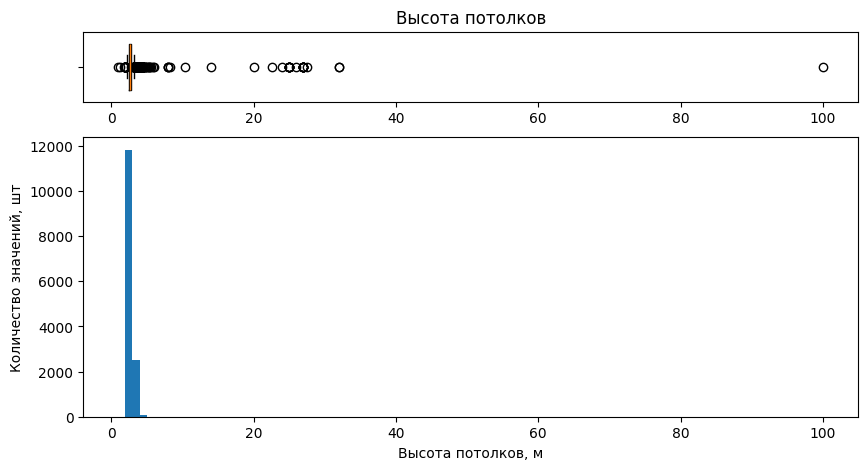

Информация о значениях столбца ceiling_height: 

Пропущенных значений: 9052

count    14429.000000
mean         2.770469
std          1.263871
min          1.000000
25%          2.510000
50%          2.650000
75%          2.800000
max        100.000000
Name: ceiling_height, dtype: float64


In [45]:
show_info('ceiling_height','Высота потолков','Высота потолков, м')

In [46]:
df.ceiling_height.sort_values(ascending = False).head(10)

22869    100.0
22336     32.0
3148      32.0
21377     27.5
10773     27.0
5246      27.0
20478     27.0
22938     27.0
21824     27.0
17857     27.0
Name: ceiling_height, dtype: float64

Видим, что часть значений лежит в диапазоне 20-32 м, вероятнее всего пользователь не указал разделитель. Поделим эти значения на 10.

In [47]:
df.loc[(df.ceiling_height >= 20) & (df.ceiling_height <= 32),'ceiling_height'] /= 10

Подсчитаем и создадим фильтр для высоты потолков от 2.4 до 4.5 метров. Выбивающиеся значения станут пропущенными, ввиду и большого кол-ва пропусков в этом столбце.  

In [48]:
df.loc[(df.ceiling_height < 2.4) | (df.ceiling_height > 4.5),'ceiling_height'].count()

42

In [49]:
df.loc[(df.ceiling_height < 2.4) | (df.ceiling_height > 4.5),'ceiling_height'] = np.nan

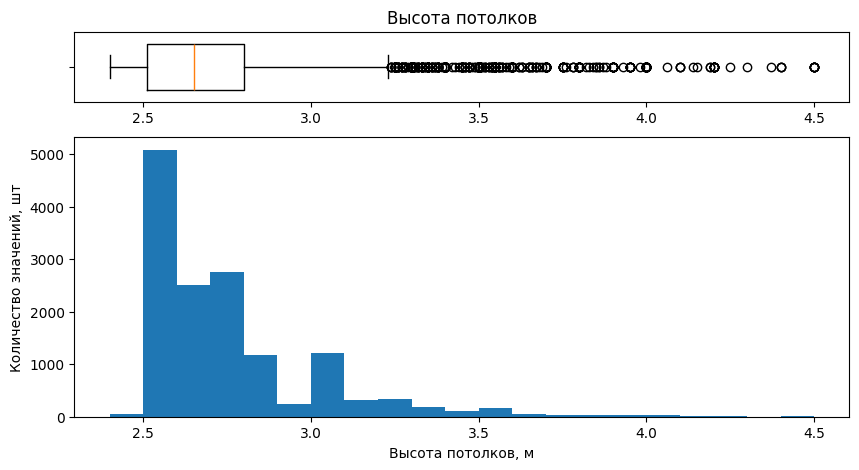

Информация о значениях столбца ceiling_height: 

Пропущенных значений: 9094

count    14387.000000
mean         2.724119
std          0.266548
min          2.400000
25%          2.510000
50%          2.650000
75%          2.800000
max          4.500000
Name: ceiling_height, dtype: float64


In [50]:
show_info('ceiling_height','Высота потолков','Высота потолков, м', bins = 21)

#### Количество комнат

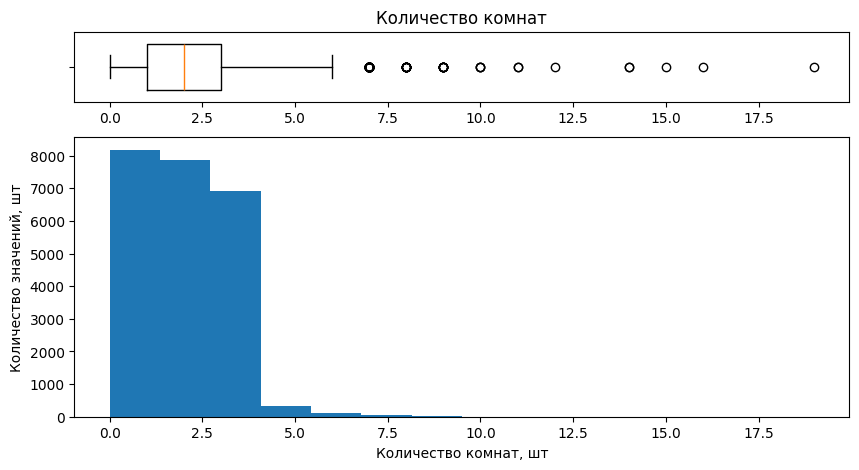

Информация о значениях столбца rooms: 

Пропущенных значений: 0

count    23481.000000
mean         2.069546
std          1.076966
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64


In [51]:
show_info('rooms','Количество комнат','Количество комнат, шт', bins = 14)

Проверим, какого типа квартиры без указания кол-ва комнат:

In [52]:
df.loc[df.rooms == 0,'studio':'open_plan'].head(5)

,studio,open_plan
144,True,False
349,False,True
440,True,False
508,False,True
608,True,False


Квартиры без комнат могут быть либо студиями, либо со свободной планировкой. Бывают ли случаи `False-False`?

In [53]:
i = {}
for index in df[df.rooms == 0].index:
    a = df.loc[index, 'studio'] + df.loc[index, 'open_plan'] # если квартира не подпадет ни под одну категорию, то выведется значение false.
    i[index] = a
pd.Series(i).unique()

array([ True])

Все значения в серии - `True`, зн случаев `False-False` не обнаружено. Нулевые значения в столбце `rooms` не являются аномалиями. Это либо студии, либо квартиры с индивидуальной планировкой.

Рассмотри кол-во аномалий.

In [54]:
df[df.rooms > 7]['rooms'].count()

31

Оставим  квартиры не более, чем с 7ю комнатами.

In [55]:
df = df.query('rooms <= 7')

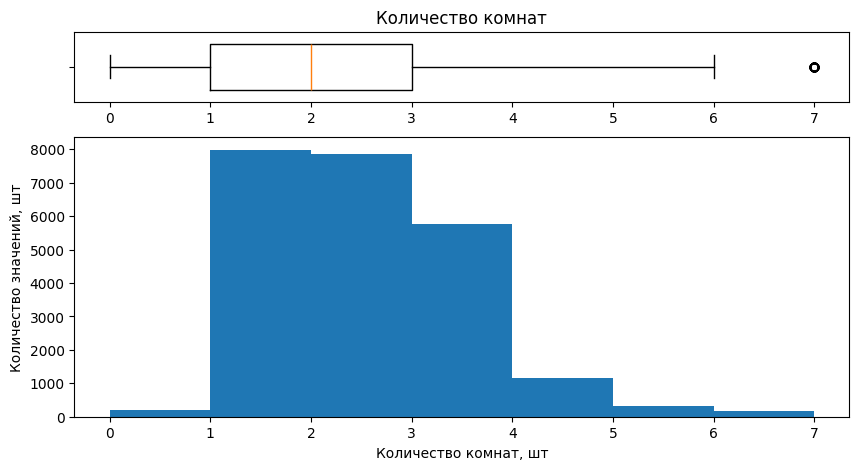

Информация о значениях столбца rooms: 

Пропущенных значений: 0

count    23450.000000
mean         2.059062
std          1.033475
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: rooms, dtype: float64


In [56]:
show_info('rooms','Количество комнат','Количество комнат, шт', bins = 7)

#### Общая площадь

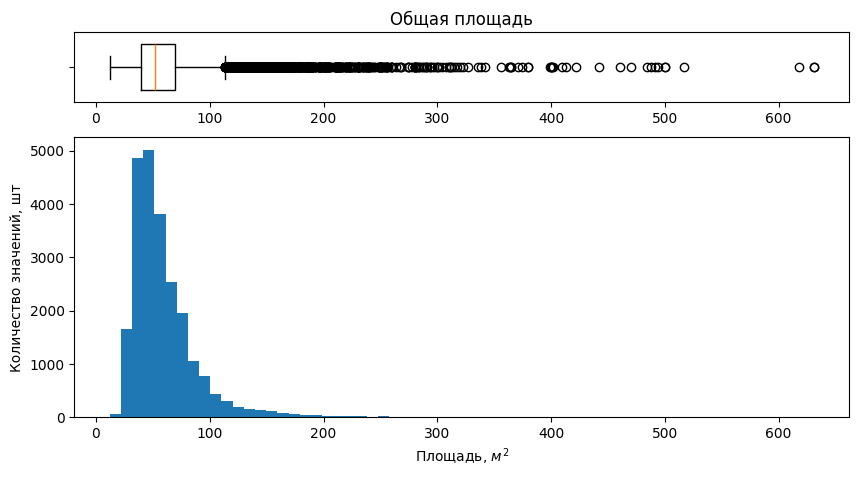

Информация о значениях столбца total_area: 

Пропущенных значений: 0

count    23450.000000
mean        59.868099
std         33.745091
min         12.000000
25%         40.000000
50%         52.000000
75%         69.300000
max        631.200000
Name: total_area, dtype: float64


In [57]:
show_info('total_area', 'Общая площадь', 'Площадь, $м^2$', bins = 63)

На графике видно, что после 200$м^2$ по оси х, значения стремятся к 0. Поэтому оставим объявления с площадью не более 250$м^2$. Тк в столбце `total_area` нет пропусков применим обычную условную конструкцию.

In [58]:
df = df[df.total_area <= 250]

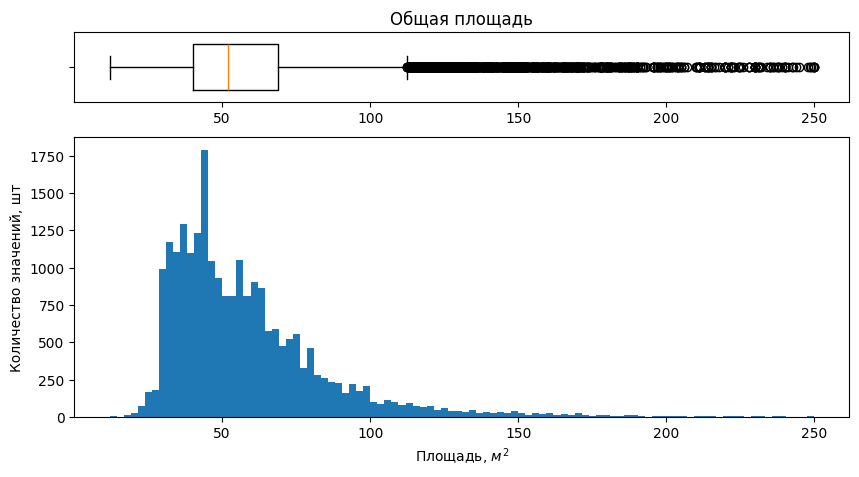

Информация о значениях столбца total_area: 

Пропущенных значений: 0

count    23359.000000
mean        58.790795
std         28.508912
min         12.000000
25%         40.000000
50%         52.000000
75%         69.000000
max        250.000000
Name: total_area, dtype: float64


In [59]:
show_info('total_area','Общая площадь','Площадь, $м^2$')

#### Жилая и кухонная площади

**Обработка пропусков**

Пропуски в столбцах `kitchen_area`, `living_area` можно заменить. Для этого найдем медианы соотношений жилой/кухонной площади к общей для квартир с разным количеством комнат (студии - квартиры с 0 комнат). 

Проверим три гипотезы:
- По мере увеличения количества комнат - растет соотношение жилой к общей площади;
- По мере увеличения количества комнат - снижается соотношение кухонной к общей площади;
- У студий соотношение площади кухни к общей должно быть равно 0, а соотношение жилой к общей - высоким.

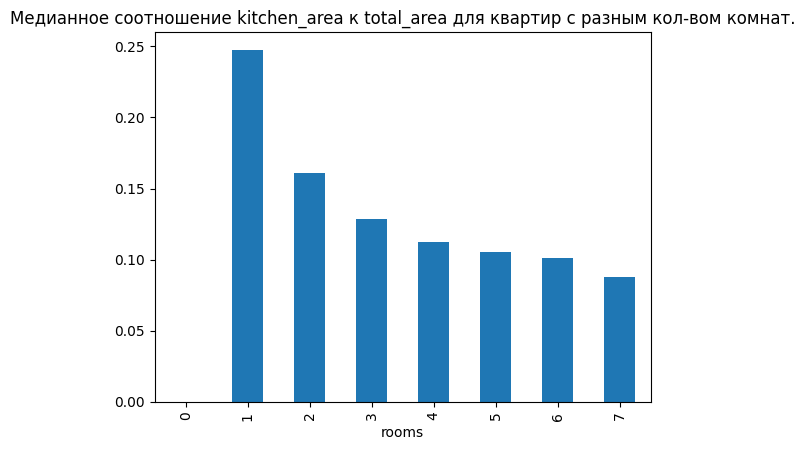

Медианное соотношение kitchen_area к total_area для квартир с разным кол-вом комнат:
 rooms
0    0.000000
1    0.247525
2    0.160985
3    0.128492
4    0.112245
5    0.105263
6    0.101441
7    0.088143
Name: kitchen_area, dtype: float64



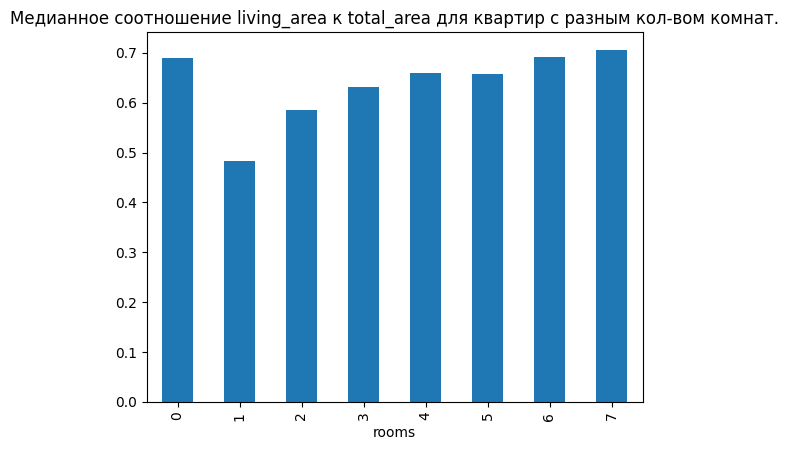

Медианное соотношение living_area к total_area для квартир с разным кол-вом комнат:
 rooms
0    0.689655
1    0.482759
2    0.585672
3    0.632124
4    0.659850
5    0.658319
6    0.692563
7    0.706145
Name: living_area, dtype: float64



In [60]:
for col in ['kitchen_area','living_area']: 
    x_area_median = (
        df[df[col].notna()] # отфильтровываем квартиры, для которых известны площади
        .groupby('rooms')[col] # группируем по количеству комнат
        .agg(lambda x: (x / df[df[col].notna()].total_area).median())) # делим на общую площадь и находим медиану
    x_area_median.plot( 
        kind = 'bar', # тип - столбчатая диаграмма
        title = f'Медианное соотношение {col} к total_area для квартир с разным кол-вом комнат.' # определим название графика
    )
    plt.show() # выводим график
    print(f'Медианное соотношение {col} к total_area для квартир с разным кол-вом комнат:\n {x_area_median}')
    print('')

Все гипотезы подтвердились. Заполним пропуски в столбцах, перемножив коэффициенты на общую площадь в каждой квартире.

In [61]:
for col in ['kitchen_area','living_area']: 
    x_area_median = (
        df[df[col].notna()] # отфильтровываем квартиры, для которых известны площади
        .groupby('rooms')[col] # группируем по количеству комнат
        .agg(lambda x: (x / df[df[col].notna()].total_area).median()) # делим на общую площадь и находим медиану
    )
    df.loc[df[col].isna(),col] = df.rooms.map(x_area_median * df.total_area) # применяем значения к столбцам

Проверим количество пропусков в столбцах.

In [62]:
check_nan(df[['kitchen_area','living_area']])

,nan_qty,nan_persent
kitchen_area,0,0.0
living_area,0,0.0


Посчитаем число строк, где сумма жилой и кухонной площадей больше, чем общая.

In [63]:
df.query('(kitchen_area+living_area) > total_area')['total_area'].count()

730

Удалим такие строки из df.

In [64]:
df = df.query('(kitchen_area+living_area) < total_area')

---

**Жилая площадь**

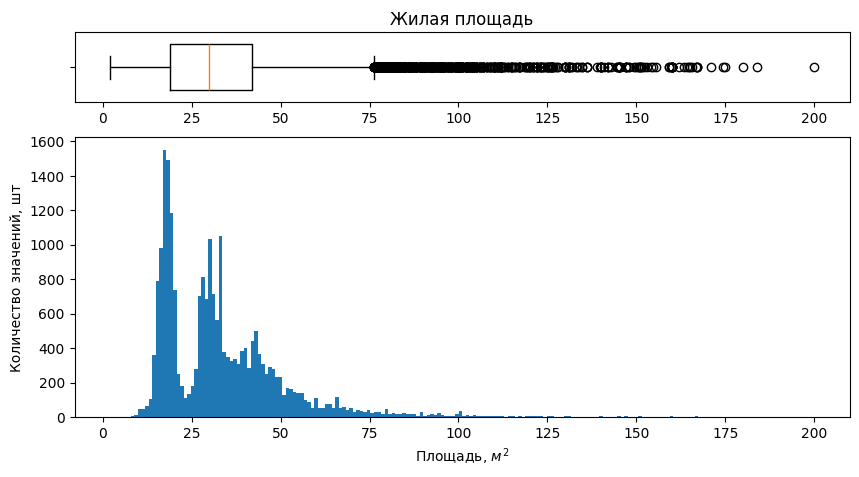

Информация о значениях столбца living_area: 

Пропущенных значений: 0

count    22553.000000
mean        33.466435
std         18.493705
min          2.000000
25%         19.000000
50%         30.000000
75%         41.900000
max        200.000000
Name: living_area, dtype: float64


In [65]:
show_info('living_area','Жилая площадь','Площадь, $м^2$', bins = 200)

Формируются три пика до 50 кв.м.:
1) В промежутке 15-20 кв.м.
2) В промежутке 25-30 кв.м.
3) В промежутке 40-50 кв.м.

Известно, что больше всего объявлений о продаже 1,2 и 3 комнатных квартир. Вероятнее всего первый пик  объединил студии и однокомнатные квартиры, а второй - двухкомнатные, третий - трехкомнатные.

In [66]:
df.groupby('rooms')['living_area'].median() # выводим медианную жилую площадь для квартир с разным кол-вом комнат

rooms
0     18.00
1     17.90
2     31.00
3     45.00
4     64.90
5     87.00
6    112.35
7    126.40
Name: living_area, dtype: float64

Да, так и есть, разброс достоверный.

---

**Площадь кухни**

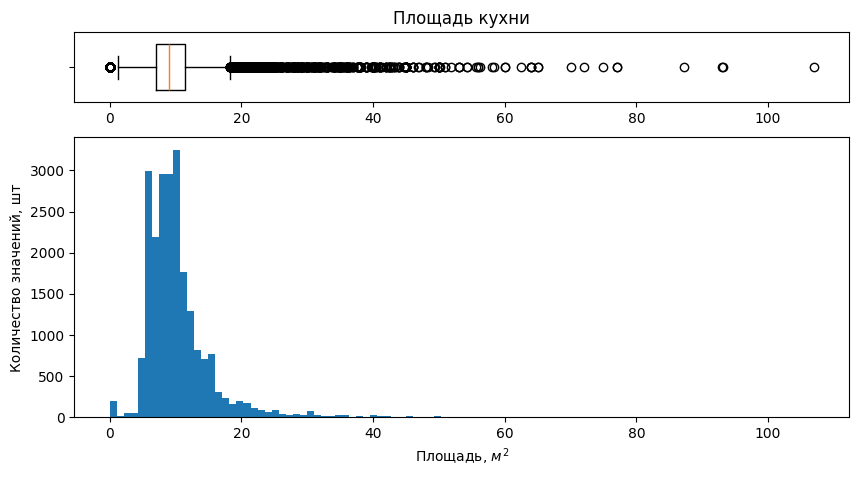

Информация о значениях столбца kitchen_area: 

Пропущенных значений: 0

count    22553.000000
mean        10.294141
std          5.428530
min          0.000000
25%          7.000000
50%          9.015152
75%         11.500000
max        107.000000
Name: kitchen_area, dtype: float64


In [67]:
show_info('kitchen_area','Площадь кухни','Площадь, $м^2$')

Выброс с площадью 0 - значения для студий, оставим это значение. Ранее мы ограничили общую площадь в 250 кв.м. и выяснили соотношение площади кухни к общей площади - от 8% до 25%, пусть среднее - 16.5%. Тогда площадь кухни не должна превышать 0.165*250 = 41 кв.м. Отсечем все значения, которые больше 45 кв.м.

In [68]:
df = df.query('kitchen_area <= 45')

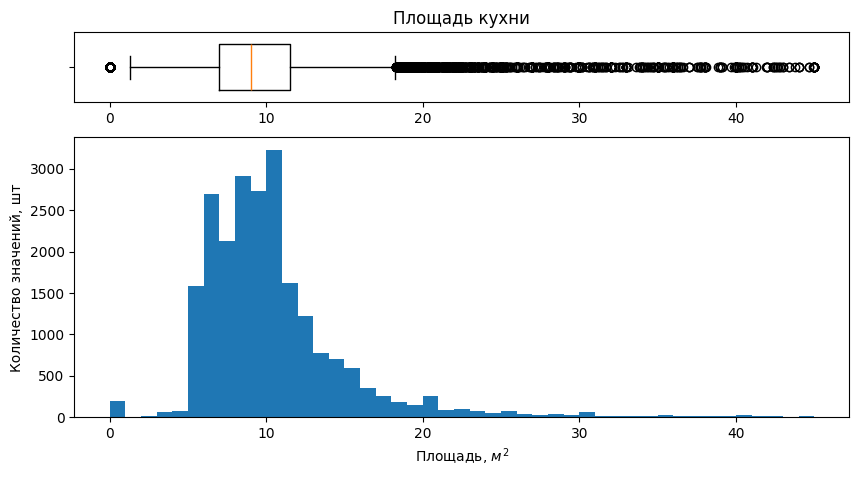

Информация о значениях столбца kitchen_area: 

Пропущенных значений: 0

count    22502.000000
mean        10.184751
std          4.881111
min          0.000000
25%          7.000000
50%          9.015152
75%         11.500000
max         45.000000
Name: kitchen_area, dtype: float64


In [69]:
show_info('kitchen_area','Площадь кухни','Площадь, $м^2$', bins = 45)

#### Цена объекта

In [70]:
df.last_price.sort_values().head()

8793      12190
17456    430000
14911    430000
16274    440000
5698     450000
Name: last_price, dtype: int64

Выбивается только одно значение - 12190.

Найдем эту строку.

In [71]:
df[df.last_price==12190]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,m2_cost,month,year,weekday,floor_type,city_center_distance
8793,7,12190,109.0,2019-03-20,2,2.75,25,32.0,25,True,False,False,40.5,0,Санкт-Петербург,36421.0,9176.0,1.0,805.0,0.0,NaN,8.0,112,3,2019,2,последний,9.0


Квартира площадью 109 кв.м. в Санкт-Петеурбрге, ожидаемо должна стоить в 1000 раз больше. Продавец указал цену в т.р.

In [72]:
df.loc[df.last_price==12190, 'last_price'] *= 1000 # домножим это значение на 1000

In [73]:
df[df.index == 8793] # проверим редактирование по индексу

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,m2_cost,month,year,weekday,floor_type,city_center_distance
8793,7,12190000,109.0,2019-03-20,2,2.75,25,32.0,25,True,False,False,40.5,0,Санкт-Петербург,36421.0,9176.0,1.0,805.0,0.0,NaN,8.0,112,3,2019,2,последний,9.0


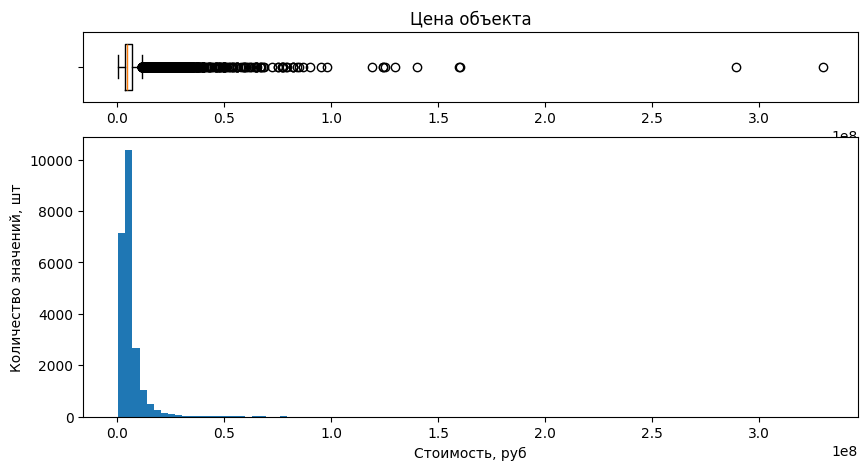

Информация о значениях столбца last_price: 

Пропущенных значений: 0

count    2.250200e+04
mean     6.103956e+06
std      6.719932e+06
min      4.300000e+05
25%      3.450000e+06
50%      4.600000e+06
75%      6.700000e+06
max      3.300000e+08
Name: last_price, dtype: float64


In [74]:
show_info('last_price','Цена объекта','Стоимость, руб')

Максимальная цена на 3 порядка отличается от минимальной. Поэтому графики не информативны. Посчитаем сколько объявлений с ценой не более 30 млн. руб (3e7).

In [75]:
print(f"""Объявлений с ценой более 30 млн.руб. : {df.query('last_price > 3e7')['last_price'].count()}""")

Объявлений с ценой более 30 млн.руб. : 199


Значений немного, поставим ограничение по цене.

In [76]:
df = df.query('last_price <= 3e7')

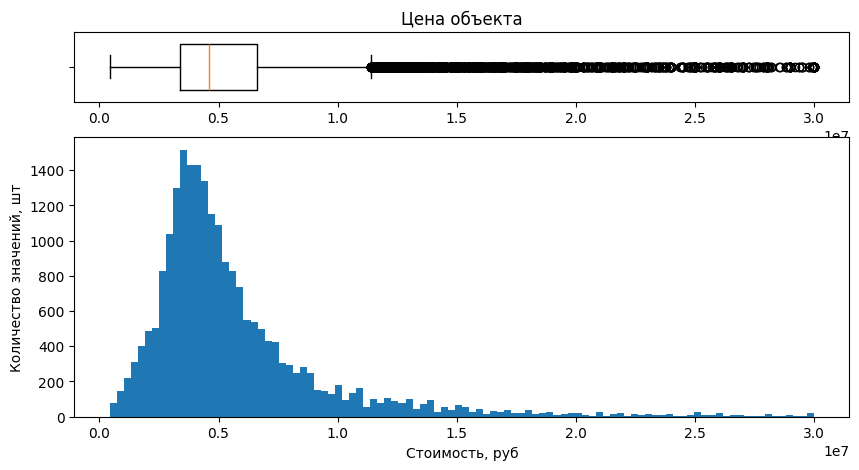

Информация о значениях столбца last_price: 

Пропущенных значений: 0

count    2.230300e+04
mean     5.690255e+06
std      3.922185e+06
min      4.300000e+05
25%      3.402500e+06
50%      4.600000e+06
75%      6.600000e+06
max      3.000000e+07
Name: last_price, dtype: float64


In [77]:
show_info('last_price','Цена объекта','Стоимость, руб')

#### Общее количество этажей

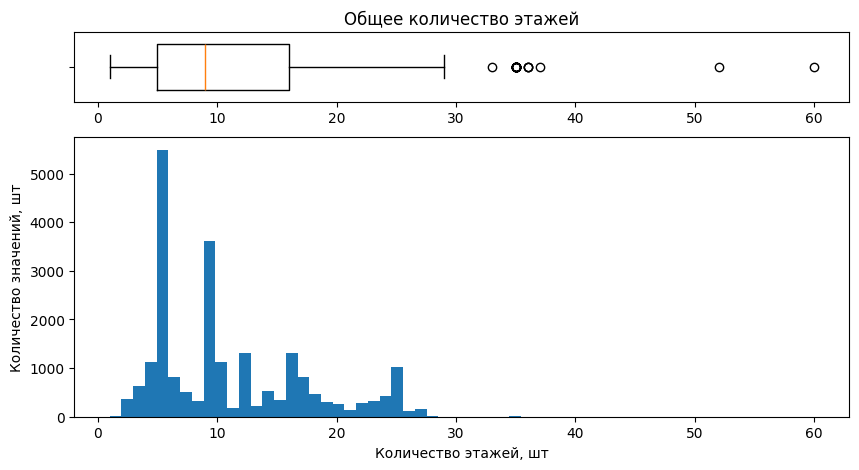

Информация о значениях столбца floors_total: 

Пропущенных значений: 0

count    22303.000000
mean        10.704569
std          6.586784
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64


In [78]:
show_info('floors_total','Общее количество этажей','Количество этажей, шт', bins = 60)

Чаще всего встречаются квартиры в домах с 5 и 9 этажами. Исторически достоверные данные. Рассмотрим квартиры в домах с 30 и более этажами.

In [79]:
df.query('floors_total > 30')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,m2_cost,month,year,weekday,floor_type,city_center_distance
397,15,5990000,54.0,2018-03-22,2,NaN,36,21.4,28,True,False,False,18.70,1,Санкт-Петербург,18732.0,20444.0,0.0,NaN,3.0,80.0,11.0,110926,3,2018,3,другой,20.0
871,14,7777777,75.0,2017-11-16,2,NaN,35,40.5,23,True,False,False,11.70,0,Санкт-Петербург,18732.0,20444.0,0.0,NaN,3.0,80.0,169.0,103704,11,2017,3,другой,20.0
1917,13,10150000,74.0,2017-11-17,2,2.80,35,34.4,30,True,False,False,13.00,0,Санкт-Петербург,18732.0,20444.0,0.0,NaN,3.0,80.0,NaN,137162,11,2017,4,другой,20.0
2253,12,3800000,45.5,2018-06-28,2,2.88,60,27.4,4,True,False,False,7.40,0,Кронштадт,67763.0,49488.0,2.0,342.0,3.0,614.0,166.0,83516,6,2018,3,другой,49.0
2966,9,4300000,37.0,2017-08-08,1,NaN,35,14.0,15,True,False,False,10.40,0,Санкт-Петербург,18732.0,20444.0,0.0,NaN,3.0,80.0,50.0,116216,8,2017,1,другой,20.0
4855,12,5500000,50.0,2017-06-22,1,2.80,35,22.0,4,True,False,False,13.00,0,Санкт-Петербург,18627.0,20339.0,1.0,609.0,3.0,145.0,537.0,110000,6,2017,3,другой,20.0
5807,17,8150000,80.0,2019-01-09,2,2.70,36,41.0,13,True,False,False,12.00,5,Санкт-Петербург,18732.0,20444.0,0.0,NaN,3.0,80.0,38.0,101875,1,2019,2,другой,20.0
5808,12,4590000,43.0,2018-10-19,1,NaN,35,14.0,11,True,False,False,15.00,0,Санкт-Петербург,18732.0,20444.0,0.0,NaN,3.0,80.0,82.0,106744,10,2018,4,другой,20.0
7236,10,4599000,42.0,2019-01-10,1,NaN,35,15.0,12,True,False,False,11.00,2,Санкт-Петербург,18732.0,20444.0,0.0,NaN,3.0,80.0,72.0,109500,1,2019,3,другой,20.0
8496,20,7500000,73.3,2017-05-18,3,NaN,35,28.0,27,True,False,False,23.10,0,Санкт-Петербург,18732.0,20444.0,0.0,NaN,3.0,80.0,250.0,102319,5,2017,3,другой,20.0


В спб есть 1 жилой дом с 35 этажами. Поэтому удалим значение 60 и 52. 

In [80]:
df = df.query('floors_total not in (52, 60)')

Строки с 33-37 этажами имеют одиннаковую отдаленность от центра, поэтому можно сказать, что это один и тот же дом. Большинство пользователей обозначили в этом доме 35 этажей. Заменим значения 33-37 на 35.

In [81]:
df.loc[df.floors_total.isin([33,34,35,36,37]), 'floors_total'] = 35

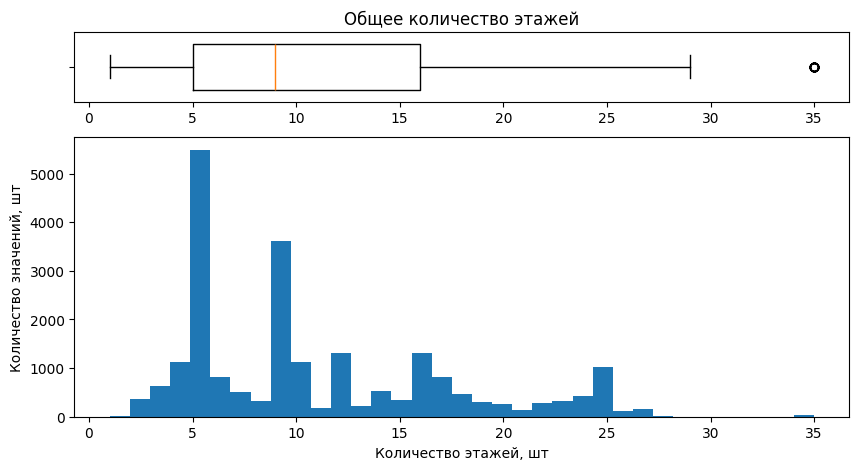

Информация о значениях столбца floors_total: 

Пропущенных значений: 0

count    22301.000000
mean        10.700372
std          6.572452
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         35.000000
Name: floors_total, dtype: float64


In [82]:
show_info('floors_total','Общее количество этажей','Количество этажей, шт', bins = 35)

#### Тип этажа

Тип этажа имеет категориальные значения, поэтому применить функцию посторения hist и boxplot не получится.

In [83]:
print(df.floor_type.describe())

count      22301
unique         3
top       другой
freq       16414
Name: floor_type, dtype: object


Посторим столбчатую диаграмму.

<Axes: title={'center': 'Распределение квартир по типу этажа'}, xlabel='floor_type'>

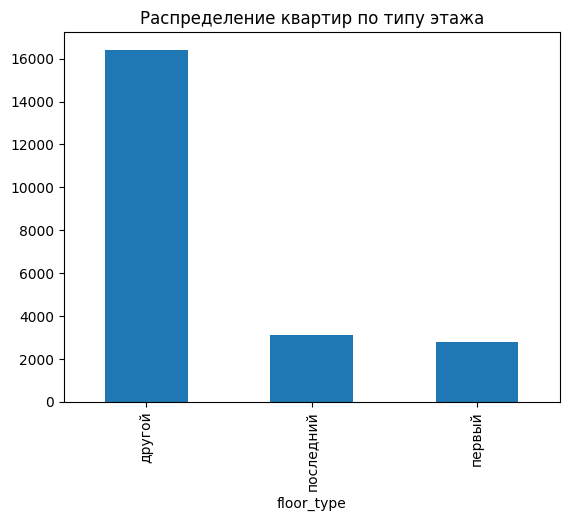

In [84]:
df.floor_type.value_counts().plot(kind = 'bar', title = 'Распределение квартир по типу этажа')

#### Расстояние до центра города в метрах

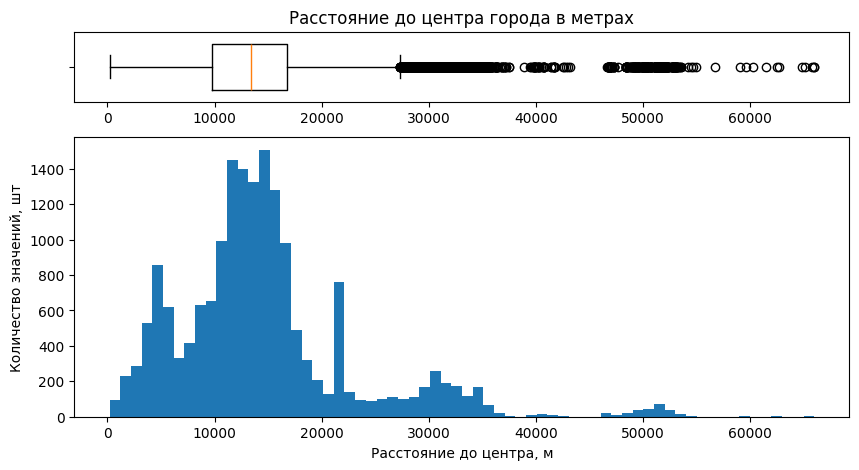

Информация о значениях столбца cityCenters_nearest: 

Пропущенных значений: 4575

count    17726.000000
mean     14655.858344
std       8620.327842
min        208.000000
25%       9800.250000
50%      13382.500000
75%      16808.000000
max      65968.000000
Name: cityCenters_nearest, dtype: float64


In [85]:
show_info('cityCenters_nearest','Расстояние до центра города в метрах','Расстояние до центра, м', bins = 66)

Оставим данный столбец без изменений, тк данные реалистичны. Наличие нескольких пиков может говорить о кластеризации квартир в разных густонаселенных районах. 

#### Расстояние до ближайшего парка

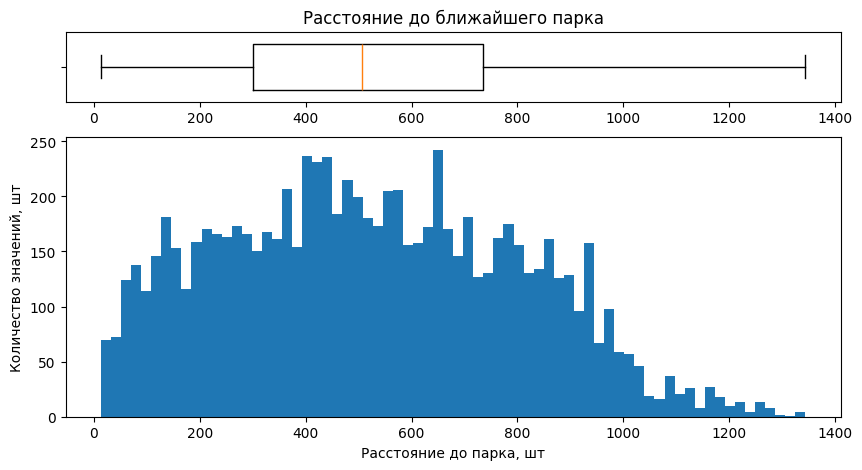

Информация о значениях столбца ponds_nearest: 

Пропущенных значений: 13821

count    8480.000000
mean      522.474646
std       278.068586
min        13.000000
25%       301.000000
50%       507.000000
75%       734.000000
max      1344.000000
Name: ponds_nearest, dtype: float64


In [86]:
show_info('ponds_nearest','Расстояние до ближайшего парка','Расстояние до парка, шт', bins = 70)

Распределение выглядит нормальным. Оставим столбец без изменений.

#### Срок продажи

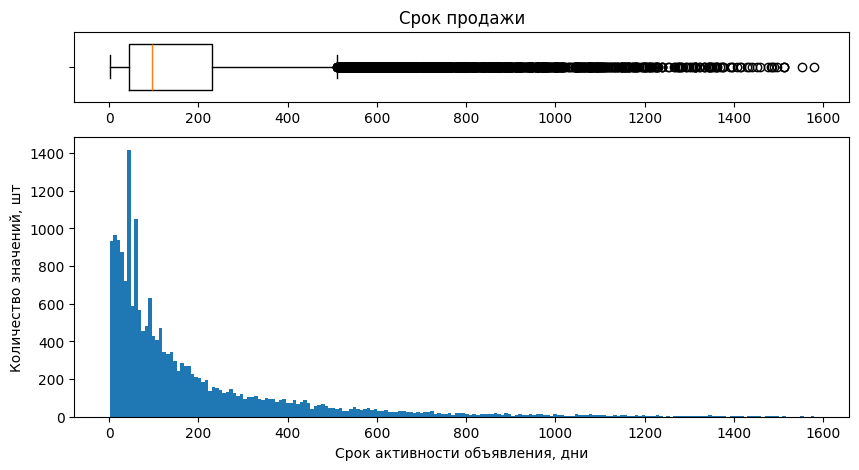

Информация о значениях столбца days_exposition: 

Пропущенных значений: 2965

count    19336.000000
mean       180.751241
std        219.189836
min          1.000000
25%         45.000000
50%         96.000000
75%        231.000000
max       1580.000000
Name: days_exposition, dtype: float64


In [87]:
show_info('days_exposition','Срок продажи','Срок активности объявления, дни',bins = 200)

Изучим промежуток от 0 до 100 дней, где видны несколько пиков.

[Text(0.5, 1.0, 'Распределение продолжительности активности объявления до 100 дней'),
 Text(0.5, 0, 'Продолжительность, дни'),
 Text(0, 0.5, 'Количество объявлений, шт')]

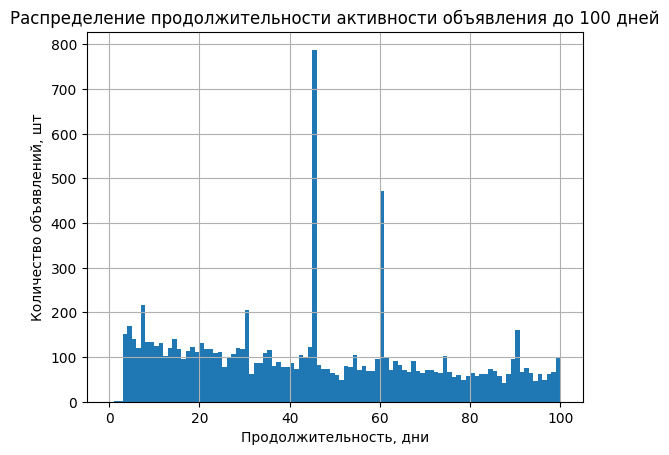

In [88]:
(
    df.days_exposition
    .hist(range = (0, 100), bins = 100)
    .set(
        title = 'Распределение продолжительности активности объявления до 100 дней', 
        xlabel = 'Продолжительность, дни', 
        ylabel = 'Количество объявлений, шт')

)

Выделяются значения `45`,`60` и `90`. Возможно, коммерческие организации, занимающиеся продажей недвижимости с такой периодичностью обновляют объявления. Поэтому снятое объявление не всегда является проданным. Удалим эти значения для более достоверной статистики.

In [89]:
df = df.query('not days_exposition in [45,60,90]')

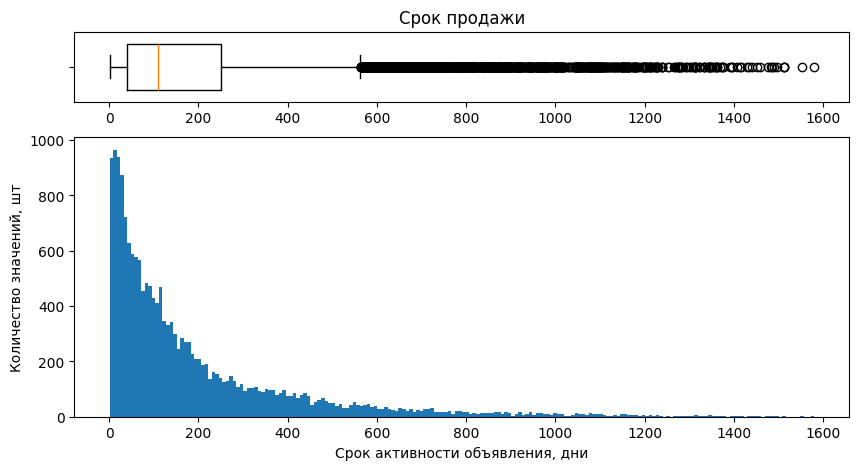

Информация о значениях столбца days_exposition: 

Пропущенных значений: 2965

count    17915.000000
mean       190.719286
std        224.693175
min          1.000000
25%         41.000000
50%        110.000000
75%        250.000000
max       1580.000000
Name: days_exposition, dtype: float64


In [90]:
show_info('days_exposition','Срок продажи','Срок активности объявления, дни', bins = 200)

Оставим объявления, срок размещения которых составляет менее 2,5 года (~900 дней).

In [91]:
print(f"""Объявлений со сроком более 900 дней: {df.query('days_exposition >= 900')['days_exposition'].count()}""")

Объявлений со сроком более 900 дней: 386


In [92]:
df = df.query('days_exposition < 900')

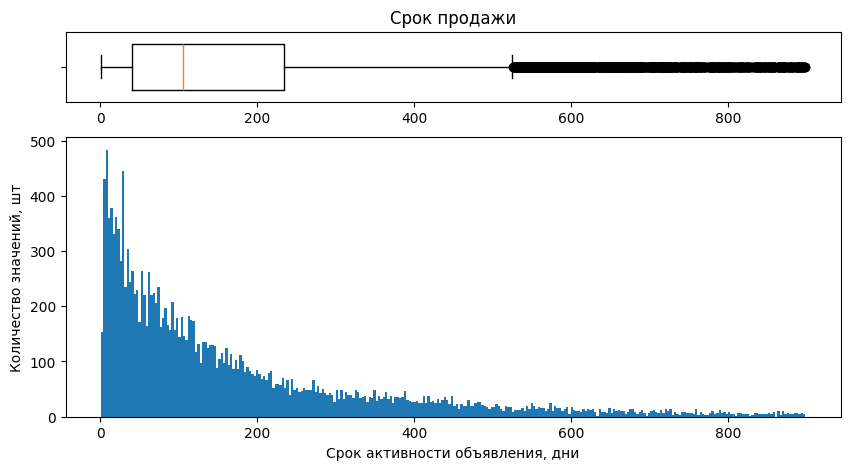

Информация о значениях столбца days_exposition: 

Пропущенных значений: 0

count    17529.000000
mean       170.807747
std        180.809705
min          1.000000
25%         40.000000
50%        106.000000
75%        234.000000
max        898.000000
Name: days_exposition, dtype: float64


In [93]:
show_info('days_exposition','Срок продажи','Срок активности объявления, дни', bins = 300)

На графике представленно распределение близкое к распределению Пуассона, где по мере увеличения времени, кол-во одновременных событий (кол-во активных объявлений) снижается.

**Можно сделать следующие выводы:**
- Среднее время продажи: 170 дней
- Медианное время продажи: 106 дней
- На основании 1 и 3 квартилей, продажа квартиры обычно занимает от 40 до 234 дней.
- Продажа считается быстрой, если клиент нашелся менее, чем за 40 день.
- Продажа считается долгой, если объявление висело 235 и более дней.

### Определение факторов, влияющих на стоимость объекта

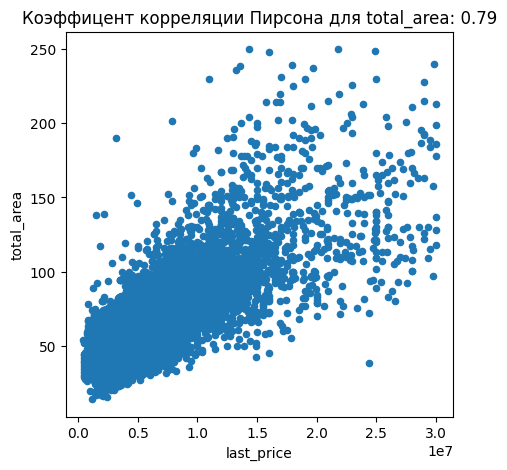

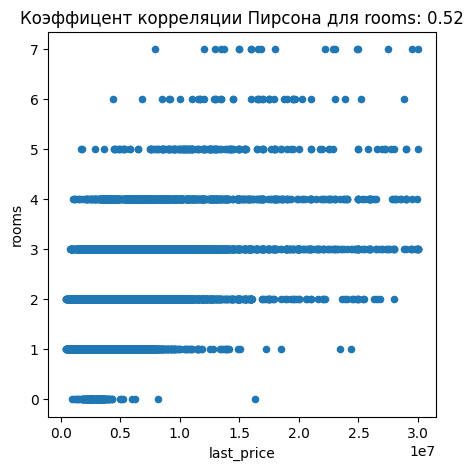

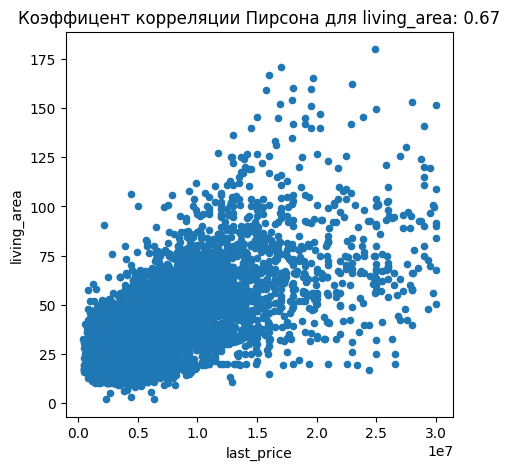

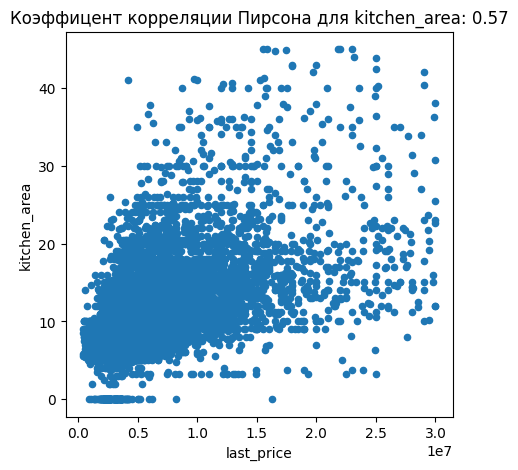

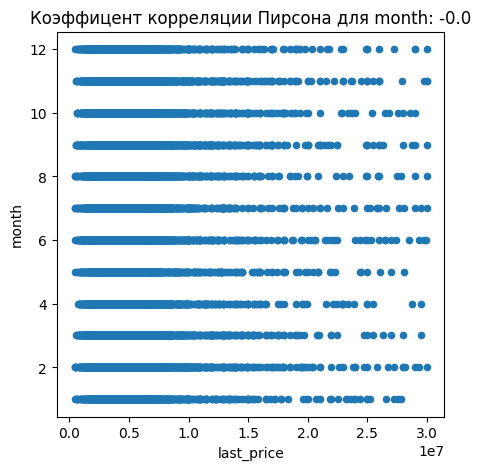

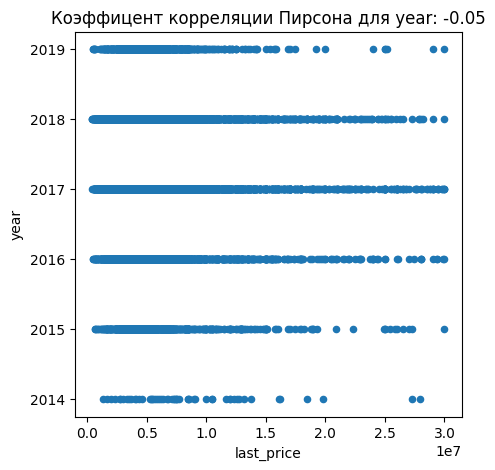

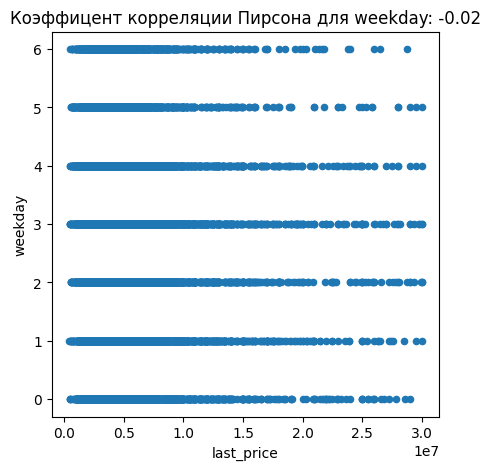

In [94]:
for col in ['total_area','rooms','living_area','kitchen_area','month','year','weekday']:
    df.plot(x='last_price', y=col, kind='scatter', figsize = (5,5)).set(title = f'Коэффицент корреляции Пирсона для {col}: {df.last_price.corr(df[col]).round(2)}')

In [95]:
df[['last_price','total_area','rooms','living_area','kitchen_area','month','year','weekday']].corr()['last_price']

last_price      1.000000
total_area      0.788244
rooms           0.515852
living_area     0.672427
kitchen_area    0.571476
month          -0.000924
year           -0.047960
weekday        -0.015789
Name: last_price, dtype: float64

Общая, жилая и кухонная площади, как и кол-во комнат, имеют сильную положительную корреляцию с ценой объекта, тогда как неделя, месяц и год не влияют на цену. 

---

Столбец `floor_type` имеет категориальные значений, поэтому посчитать корреляцию с ценой квартиры с помощью коэффицента Пирсона не получится, поэтому сравним средние значения цен для каждой группы этажей. Ранее выборку обработали от аномалий по многим параметрам, поэтому использовать медианное здесь не обязательно.

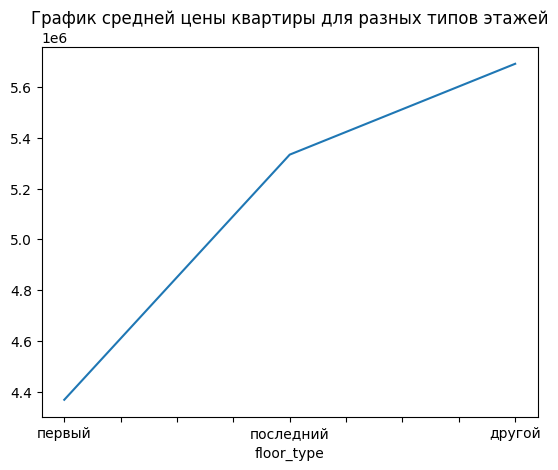

In [104]:
(
    df.groupby('floor_type')['last_price'].mean()
    .sort_values().plot(title = 'График средней цены квартиры для разных типов этажей')
)
plt.show()

Видим, что некоторая зависмость есть: в среднем, квартиры на первом этаже дешевле, чем на последнем. А с типом "другой" - еще дороже, хотя и не сильно.

### Населённые пункты с наибольшим числом объявлений

Создадим сводную таблицу, чтобы вывести среднюю стоимость за квадратный метр в топ-10 населенных пунктах по числу объявлений.

In [97]:
pivot = df.pivot_table(index = 'locality_name',values = 'm2_cost',aggfunc = ['count', 'mean'])
pivot.columns = ['count_m2', 'mean_m2'] # избавимся от двухярусности в названиях
(
    pivot.sort_values(by = 'count_m2', ascending = False).head(10) # отсортируем в порядке убывания кол-ва объявлений и выведем 10 первых значений
    .sort_values(by='mean_m2', ascending = False) # повторно отсортируем в порядке убывания по средней стоимости кв.м.
)

,count_m2,mean_m2
locality_name,,
Санкт-Петербург,11773,107993.311645
Пушкин,272,102300.702206
Кудрово,361,93791.390582
поселок Парголово,259,89892.135135
Мурино,464,85389.122845
поселок Шушары,359,77717.440111
Колпино,270,74875.800000
Всеволожск,292,68784.174658
Гатчина,235,67639.238298


Наибольшая стоимость за кв.м. в Санкт-Петербурге, Пушкине и Кудрово, минимальная в Гатчине и Выборге.

### Средняя стоимость квартир на разном удалении от центра в Санкт-Петербурге

Для определения стоимости квартир на разном удалении от центра создадим сводную таблицу. Далее для наглядности выведем диаграмму.

city_center_distance,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0
m2_cost,129812.0,132688.0,124726.0,111340.0,121794.0,129129.0,129291.0,127726.0,120262.0,109816.0,109657.0,104928.0,105895.0,106043.0,102699.0,102139.0,98679.0,96671.0,96268.0,98379.0,98636.0,91463.0,89016.0,88129.0,83991.0,91179.0,87270.0,132116.0,81162.0,75326.0


<Axes: title={'center': 'Средняя стоимость за $м^2$ на разном отдалении от центра в Санкт-Петербурге'}, xlabel='city_center_distance'>

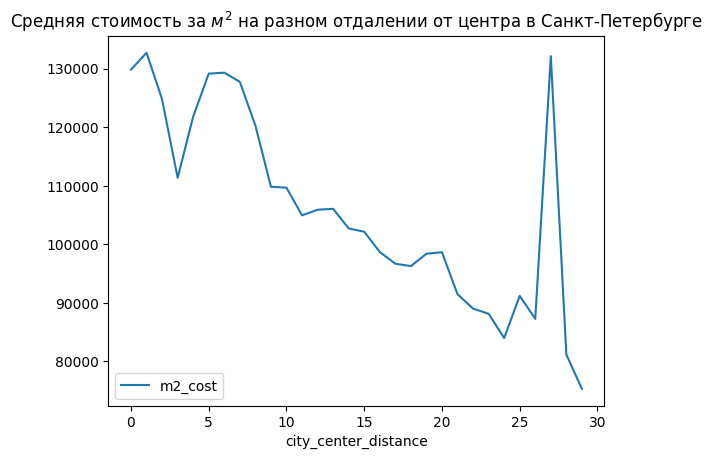

In [98]:
pivot_m2 = ( 
    df.query('locality_name == "Санкт-Петербург"') # оставляем только объявления из Санкт-Петербурга
    .pivot_table( # считаем среднее, поэтому aggfunc не обозначаем
        index = 'city_center_distance', # исползуем ранее созданный столбец с расстоянием в км
        values = 'm2_cost' # значения - стоимость за кв.м.
    )
    
).round(0) # округлим значения до целых
display(pivot_m2.T) # для наглядности транспонируем
pivot_m2.plot(title = 'Средняя стоимость за $м^2$ на разном отдалении от центра в Санкт-Петербурге') # выведем диаграмму

На диаграмме виден пик в районе 27 км от центра, проверим почему так.

In [99]:
df.query('(locality_name == "Санкт-Петербург") & city_center_distance == 27')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,m2_cost,month,year,weekday,floor_type,city_center_distance
748,13,14350000,74.0,2017-11-28,2,3.13,5,30.0,3,True,False,False,25.0,0,Санкт-Петербург,23888.0,27313.0,1.0,1496.0,0.0,NaN,128.0,193919,11,2017,1,другой,27.0
5961,6,2250000,32.0,2018-02-27,1,NaN,2,16.5,2,True,False,False,7.0,0,Санкт-Петербург,24006.0,27431.0,0.0,NaN,0.0,NaN,178.0,70312,2,2018,1,последний,27.0


Малое количество объявлений, еще и сильно отличающихся по стоимости, делает среднюю не совсем реалистичной. Заменим 27 на 28 км, чтобы средняя формировалась из большего числа объявлений.

In [100]:
df.loc[(df.locality_name == "Санкт-Петербург") & (df.city_center_distance == 27),'city_center_distance'] = 28

Повторно выведем цену за кв.м.

city_center_distance,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0
m2_cost,129812.0,132688.0,124726.0,111340.0,121794.0,129129.0,129291.0,127726.0,120262.0,109816.0,109657.0,104928.0,105895.0,106043.0,102699.0,102139.0,98679.0,96671.0,96268.0,98379.0,98636.0,91463.0,89016.0,88129.0,83991.0,91179.0,87270.0,132116.0,81162.0,75326.0


<Axes: title={'center': 'Средняя стоимость за $м^2$ на разном отдалении от центра в Санкт-Петербурге'}, xlabel='city_center_distance'>

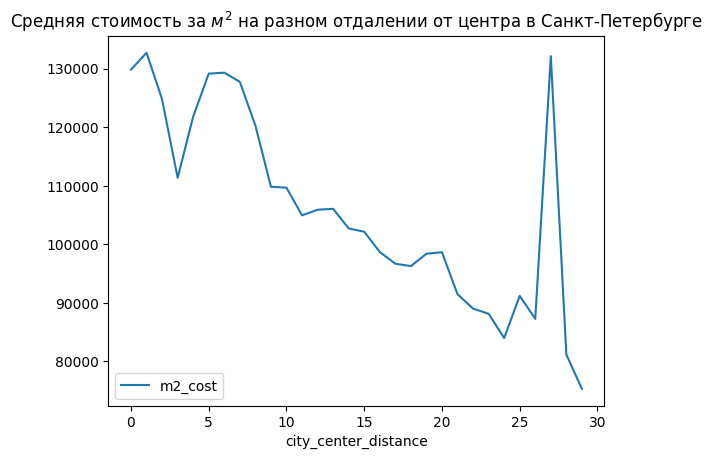

In [101]:
display(pivot_m2.T) # для наглядности транспонируем
pivot_m2.plot(title = 'Средняя стоимость за $м^2$ на разном отдалении от центра в Санкт-Петербурге') # выведем диаграмму

После обработки видим, что средняя стоимость за кв.м. достаточно равномерно уменьшается по мере отдаления от центра. 
Колебания вверх/вниз могут указывать на специфику района города.

---

То же самое проделаем для стоимости квартир в Санкт-Петерубрге.

city_center_distance,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,28.0,29.0
last_price,11365000.0,11520752.0,10556301.0,8981484.0,9608615.0,10259532.0,9225531.0,8761948.0,8131436.0,6501220.0,5907508.0,5745596.0,5611788.0,5820403.0,5393926.0,5461495.0,5127758.0,5134208.0,4699870.0,4996529.0,5756872.0,5032740.0,5071923.0,4546927.0,3861199.0,4165814.0,3998272.0,5753889.0,4050000.0


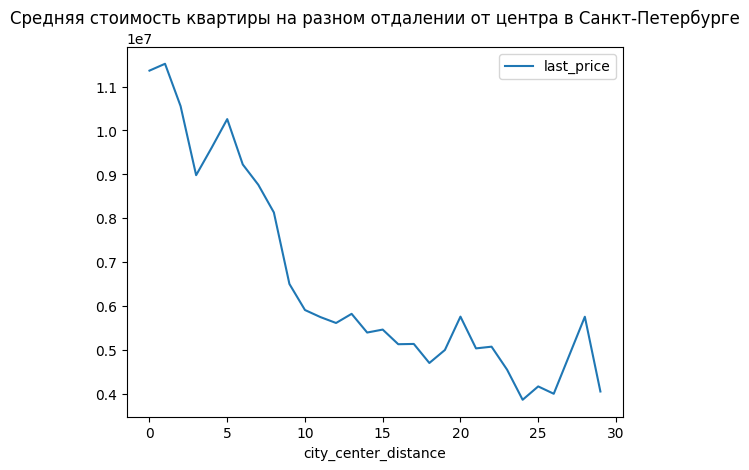

In [102]:
pivot_m2 = ( 
    df.query('locality_name == "Санкт-Петербург"') # оставляем только объявления из Санкт-Петербурга
    .pivot_table( # считаем среднее, поэтому aggfunc не обозначаем
        index = 'city_center_distance', # исползуем ранее созданный столбец с расстоянием в км
        values = 'last_price' # значения - стоимость квартиры
    )
    
).round(0) # округлим значения до целых
display(pivot_m2.T) # для наглядности транспонируем
pivot_m2.plot(title = 'Средняя стоимость квартиры на разном отдалении от центра в Санкт-Петербурге') # выведем диаграмму
plt.show()

График имеет схожую динамику с графиком стоимости за кв.м. Чем дальше от центра, тем дешевле средняя стоимость квартиры в Санкт-Петербурге. Причем в центре города (радиус около 10 км) цены на квартиры резко увеличиваются.

In [103]:
df.query('locality_name == "Санкт-Петербург"')['last_price'].corr(df.city_center_distance)

-0.4098366984110353

Также это подтверждает отрицательное значение коэффицента корреляции Пирсона.

## Общий вывод

**A)** Сильнее всего на стоимость объекта влияют следующие параметры (в порядке убывания):
1. Общая площадь (также жилая и площадь кухни);
2. Количество комнат;
3. Близость к центру города (для Санкт-Петербурга);
4. Этаж квартиры (первый < послений < другой).

Для дня недели, месяца и года корреляции с ценой не было обнаружено.

**Б)** Сильно выделялись некоторые значения в продолжительности активности объявлений: 45,60 и 90. Возможно, коммерческие организации, занимающиеся продажей недвижимости с такой периодичностью обновляют объявления. Было принято решение исключить их из выборки.

**B)** Был выделен список для 10 городов с наибольшим числом объявлений:

- Санкт-Петербург - 12121
- Мурино - 502
- Кудрово - 386
- поселок Шушары - 367
- Всеволожск - 302
- Пушкин - 279
- Колпино - 272
- поселок Парголово - 262
- Гатчина - 240
- Выборг - 178
  
Наибольшая стоимость за кв.м. наблюдалась в Санкт-Петербурге - 108300, Пушкине - 102300 и Кудрово - 93800, минимальная в Гатчине - 67600 и Выборге - 57100.

**Г)** Определены важные параметры и сделаны дополнительные выводы:
- Среднее время продажи: 170 дней
- Медианное время продажи: 106 дней
- На основании 1 и 3 квартилей, продажа квартиры обычно занимает от 40 до 234 дней.
- Продажа считается быстрой, если клиент нашелся менее, чем за 40 день.
- Продажа считается долгой, если объявление висело 235 и более дней.

**Д)** Выделен ряд причин появления пропусков:
- Ошибка в работе геосервиса: `ponds_around3000`, `parks_around3000`, `airports_nearest`, `parks_nearest`.
- Ошибка иной системы: `days_exposition`.
- Логичное появление пропуска: `ponds_nearest`, `cityCenters_nearest`.
- Иные пропуски могут свидетельствовать о возможности пропускать поля ввода при создании объявлений.